In [1]:
import requests
import pandas as pd
from urllib import parse
import json
import time
import pickle
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

api_key = "RGAPI-3a0389a6-f001-48b2-ac2b-b226fa0300f8"#api_key

champions_id={      #champion list
    266: "Aatrox",
    412: "Thresh",
    23: "Tryndamere",
    79: "Gragas",
    69: "Cassiopeia",
    136: "Aurelion Sol",
    13: "Ryze",
    78: "Poppy",
    14: "Sion",
    1: "Annie",
    202: "Jhin",
    43: "Karma",
    111: "Nautilus",
    240: "Kled",
    99: "Lux",
    103: "Ahri",
    2: "Olaf",
    112: "Viktor",
    34: "Anivia",
    27: "Singed",
    86: "Garen",
    127: "Lissandra",
    57: "Maokai",
    25: "Morgana",
    28: "Evelynn",
    105: "Fizz",
    74: "Heimerdinger",
    238: "Zed",
    68: "Rumble",
    82: "Mordekaiser",
    37: "Sona",
    96: "Kog'Maw",
    55: "Katarina",
    117: "Lulu",
    22: "Ashe",
    30: "Karthus",
    12: "Alistar",
    122: "Darius",
    67: "Vayne",
    110: "Varus",
    77: "Udyr",
    89: "Leona",
    126: "Jayce",
    134: "Syndra",
    80: "Pantheon",
    92: "Riven",
    121: "Kha'Zix",
    42: "Corki",
    268: "Azir",
    51: "Caitlyn",
    76: "Nidalee",
    85: "Kennen",
    3: "Galio",
    45: "Veigar",
    432: "Bard",
    150: "Gnar",
    90: "Malzahar",
    104: "Graves",
    254: "Vi",
    10: "Kayle",
    39: "Irelia",
    64: "Lee Sin",
    420: "Illaoi",
    60: "Elise",
    106: "Volibear",
    20: "Nunu",
    4: "Twisted Fate",
    24: "Jax",
    102: "Shyvana",
    429: "Kalista",
    36: "Dr. Mundo",
    427: "Ivern",
    131: "Diana",
    223: "Tahm Kench",
    63: "Brand",
    113: "Sejuani",
    8: "Vladimir",
    154: "Zac",
    421: "Rek'Sai",
    133: "Quinn",
    84: "Akali",
    163: "Taliyah",
    18: "Tristana",
    120: "Hecarim",
    15: "Sivir",
    236: "Lucian",
    107: "Rengar",
    19: "Warwick",
    72: "Skarner",
    54: "Malphite",
    157: "Yasuo",
    101: "Xerath",
    17: "Teemo",
    75: "Nasus",
    58: "Renekton",
    119: "Draven",
    35: "Shaco",
    50: "Swain",
    91: "Talon",
    40: "Janna",
    115: "Ziggs",
    245: "Ekko",
    61: "Orianna",
    114: "Fiora",
    9: "Fiddlesticks",
    31: "Cho'Gath",
    33: "Rammus",
    7: "LeBlanc",
    16: "Soraka",
    26: "Zilean",
    56: "Nocturne",
    222: "Jinx",
    83: "Yorick",
    6: "Urgot",
    203: "Kindred",
    21: "Miss Fortune",
    62: "Wukong",
    53: "Blitzcrank",
    98: "Shen",
    201: "Braum",
    5: "Xin Zhao",
    29: "Twitch",
    11: "Master Yi",
    44: "Taric",
    32: "Amumu",
    41: "Gangplank",
    48: "Trundle",
    38: "Kassadin",
    161: "Vel'Koz",
    143: "Zyra",
    267: "Nami",
    59: "Jarvan IV",
    81: "Ezreal",
    350: "Yuumi",
    145: "Kai'sa",
    518: "Neeko",
    142: "Zoe",
    498: "Xayah",
    517: "Sylas",
    141: "Kayn",
    516: "Ornn",
    555: "Pyke",
    164: "Camille",
    246: "Qiyana",
    497: "Rakan",
    235: "Senna",
    523: "Aphelios",
    875: "Sett",
    876: "Lillia",
    777: "Yone",
    360: "Samira",
    147: "Seraphine",
    526: "Rell",
    234: "Viego",
    887: "Gwen",
    166: "Akshan"
}
queue_type = {    #queue type list
    450: "ARAM",
    440: "Flex 5:5 Rank",
    430: "Normal",
    420: "Solo Rank",
    830: "Bot"
}

In [2]:
CHALLENGER_URL ="https://kr.api.riotgames.com/lol/league/v4/challengerleagues/by-queue/RANKED_SOLO_5x5?api_key="+api_key
MASTER_URL ="https://kr.api.riotgames.com/lol/league/v4/masterleagues/by-queue/RANKED_SOLO_5x5?api_key="+api_key
GRANDMASTER_URL ="https://kr.api.riotgames.com/lol/league/v4/grandmasterleagues/by-queue/RANKED_SOLO_5x5?api_key="+api_key
summoner_id_list = []
#top tier api list

URL_list = [CHALLENGER_URL,MASTER_URL,GRANDMASTER_URL]

for x in URL_list:
    req = requests.get(x)
    for i in range(len(req.json()['entries'])):
        summoner_id_list.append(req.json()['entries'][i]['summonerId'])
        
    #top tier summonerid append in summoner_id_list

In [3]:
summoner_info_URL = "https://kr.api.riotgames.com/lol/summoner/v4/summoners/{}?api_key="+api_key
account_id = []     #summoner info URL
#because i want to get account id.

for x in range(len(summoner_id_list)):
    summoner_info_req = requests.get(summoner_info_URL.format(summoner_id_list[x]))
    if summoner_info_req.status_code == 200:     #status_code is 200, pass(beacuase api request limit)
        pass
    elif summoner_info_req.status_code == 429:
        start_time = time.time()
        while True:
            if summoner_info_req.status_code == 429:
                time.sleep(82)

                summoner_info_req = requests.get(summoner_info_URL.format(summoner_id_list[x]))

            elif summoner_info_req.status_code == 200:
                break
    account_id.append(summoner_info_req.json()['accountId'])
    


In [4]:
#save pickle
 
with open( "account_id_list", "wb" ) as file:
    pickle.dump( account_id, file)

In [5]:
with open( "account_id_list", "rb" ) as file:     #load pickle
    account_id_pickle_data = pickle.load(file)

In [6]:
matchlists = "https://kr.api.riotgames.com/lol/match/v4/matchlists/by-account/{}?champion={}&beginTime={}&api_key="+api_key
#accountId, champion, beginTime(unix)
champion_num = 166
begin_time = 1627077600000 #lol last patch day
game_id = []
for x in range(len(account_id_pickle_data)):
    match_req = requests.get(matchlists.format(account_id_pickle_data[x],champion_num,begin_time))
    if match_req.status_code == 404 or match_req.status_code == 403:
        continue
    elif match_req.status_code == 200:
        pass
    
    elif match_req.status_code == 429:
        start_time = time.time()
        while True:
            if match_req.status_code == 429:
                time.sleep(82)

                match_req = requests.get(matchlists.format(account_id_pickle_data[x],champion_num,begin_time))

            elif match_req.status_code == 200 or match_req.status_code == 404 or match_req.status_code == 403:
                break
    if match_req.status_code == 404 or match_req.status_code == 403:
        continue
    elif match_req.status_code == 503:
        break
    for x in range(len(match_req.json()['matches'])):
        game_id.append(match_req.json()['matches'][x]['gameId'])

In [7]:
with open( "game_id_list", "wb" ) as file:
    pickle.dump( game_id, file)

In [8]:
with open( "game_id_list", "rb" ) as file:     #load pickle
    game_id_pickle_data = pickle.load(file)
game_id_pickle_data
champion_num = 166    #akshan

In [9]:
game_id_URL = "https://kr.api.riotgames.com/lol/match/v4/matches/{}?api_key="+api_key
match_info = []
#match data collect

for x in range(len(game_id_pickle_data)):
    game_id_req = requests.get(game_id_URL.format(game_id_pickle_data[x]))
    
    if game_id_req.status_code == 404 or game_id_req.status_code == 403:
        continue
    elif game_id_req.status_code == 200:
        pass
    
    elif game_id_req.status_code == 429:
        start_time = time.time()
        while True:
            if game_id_req.status_code == 429:
                time.sleep(82)

                game_id_req = requests.get(game_id_URL.format(game_id_pickle_data[x]))

            elif game_id_req.status_code == 200 or game_id_req.status_code == 404:
                break
    if game_id_req.status_code == 404 or game_id_req.status_code == 403:
        continue
    if game_id_req.json()['queueId'] != 420:  #only solo rank data
        continue
    for x in range(10):
        if game_id_req.json()['participants'][x]['championId'] == champion_num:
            match_info.append(game_id_req.json()['participants'][x])

In [10]:
with open( "akshan_match_list", "wb" ) as file:
    pickle.dump( match_info, file)

In [11]:
with open( "akshan_match_list", "rb" ) as file:     #load pickle
    akshan_match_data = pickle.load(file)

In [12]:
LOL_data_info_URL = "http://ddragon.leagueoflegends.com/cdn/11.15.1/data/en_US/item.json"
LOL_data_info_req =  requests.get(LOL_data_info_URL)
items_keys = list(LOL_data_info_req.json()['data'].keys())
items_dict = {}        #LOL item data
for x in range(len(items_keys)):
    items_dict[items_keys[x]] = LOL_data_info_req.json()['data'][items_keys[x]]['name']
print(items_dict)

{'1001': 'Boots', '1004': 'Faerie Charm', '1006': 'Rejuvenation Bead', '1011': "Giant's Belt", '1018': 'Cloak of Agility', '1026': 'Blasting Wand', '1027': 'Sapphire Crystal', '1028': 'Ruby Crystal', '1029': 'Cloth Armor', '1031': 'Chain Vest', '1033': 'Null-Magic Mantle', '1035': 'Emberknife', '1036': 'Long Sword', '1037': 'Pickaxe', '1038': 'B. F. Sword', '1039': 'Hailblade', '1042': 'Dagger', '1043': 'Recurve Bow', '1052': 'Amplifying Tome', '1053': 'Vampiric Scepter', '1054': "Doran's Shield", '1055': "Doran's Blade", '1056': "Doran's Ring", '1057': 'Negatron Cloak', '1058': 'Needlessly Large Rod', '1082': 'Dark Seal', '1083': 'Cull', '2003': 'Health Potion', '2010': 'Total Biscuit of Everlasting Will', '2015': 'Kircheis Shard', '2031': 'Refillable Potion', '2033': 'Corrupting Potion', '2051': "Guardian's Horn", '2052': 'Poro-Snax', '2055': 'Control Ward', '2065': "Shurelya's Battlesong", '2138': 'Elixir of Iron', '2139': 'Elixir of Sorcery', '2140': 'Elixir of Wrath', '2403': 'Min

In [13]:
LOL_spell_data_URL = "http://ddragon.leagueoflegends.com/cdn/11.15.1/data/en_US/summoner.json"
LOL_spell_data_req = requests.get(LOL_spell_data_URL)
spell_keys = list(LOL_spell_data_req.json()['data'].keys())
spells_dict = {}            #LOL spell data
for x in range(len(spell_keys)):
    spells_dict[spell_keys[x]] = LOL_spell_data_req.json()['data'][spell_keys[x]]['key']
print(spells_dict)

{'SummonerBarrier': '21', 'SummonerBoost': '1', 'SummonerDot': '14', 'SummonerExhaust': '3', 'SummonerFlash': '4', 'SummonerHaste': '6', 'SummonerHeal': '7', 'SummonerMana': '13', 'SummonerPoroRecall': '30', 'SummonerPoroThrow': '31', 'SummonerSmite': '11', 'SummonerSnowURFSnowball_Mark': '39', 'SummonerSnowball': '32', 'SummonerTeleport': '12', 'Summoner_UltBook_Placeholder': '54'}


In [14]:
stats_keys = ['spell1Id', 'spell2Id', 'win', 'item0', 'item1', 'item2', 'item3', 'item4', 'item5', 'item6', 'kills', 'deaths', 'assists', 'doubleKills', 'tripleKills', 'quadraKills', 'pentaKills', 'totalDamageDealtToChampions', 'magicDamageDealtToChampions', 'physicalDamageDealtToChampions', 'trueDamageDealtToChampions', 'visionScore', 'goldEarned', 'turretKills', 'inhibitorKills', 'totalMinionsKilled', 'champLevel', 'firstBloodKill', 'firstTowerKill', 'perk0', 'perk0Var1', 'perk0Var2', 'perk0Var3', 'perk1', 'perk1Var1', 'perk1Var2', 'perk1Var3', 'perk2', 'perk2Var1', 'perk2Var2', 'perk2Var3', 'perk3', 'perk3Var1', 'perk3Var2', 'perk3Var3', 'perk4', 'perk4Var1', 'perk4Var2', 'perk4Var3', 'perk5', 'perk5Var1', 'perk5Var2', 'perk5Var3', 'perkPrimaryStyle', 'perkSubStyle', 'statPerk0', 'statPerk1', 'statPerk2']

In [15]:
akshan_df = []     #make dataframe
for x in range(len(akshan_match_data)):
    data_list = []
    for k in range(len(stats_keys)):
        if k < 2:
            data_list.append(akshan_match_data[x][stats_keys[k]])
        else:
            if stats_keys[k] in akshan_match_data[x]['stats']:
                data_list.append(akshan_match_data[x]['stats'][stats_keys[k]])
            else:
                data_list.append('NaN')
    akshan_df.append(data_list)

In [16]:
akshan_df = pd.DataFrame(akshan_df)
akshan_df.columns = stats_keys
akshan_df

,spell1Id,spell2Id,win,item0,item1,item2,item3,item4,item5,item6,...,perk4Var3,perk5,perk5Var1,perk5Var2,perk5Var3,perkPrimaryStyle,perkSubStyle,statPerk0,statPerk1,statPerk2
0,7,4,True,6671,3047,6676,1055,1018,0,3363,...,0,8347,0,0,0,8000,8300,5005,5008,5002
1,7,4,False,3047,1055,6670,1053,1018,0,3340,...,0,8135,237,1,0,8000,8100,5005,5008,5002
2,14,4,True,3047,2031,0,1055,3091,6672,3363,...,0,8473,617,0,0,8000,8400,5005,5008,5002
3,14,4,False,1036,3047,1057,1055,3153,6672,3363,...,0,8473,617,0,0,8000,8400,5005,5008,5002
4,14,4,True,1037,1055,1036,3047,3091,6672,3363,...,0,8473,582,0,0,8000,8400,5005,5008,5003
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
791,14,4,True,2031,2055,3091,3006,6672,1055,3340,...,0,8135,1770,5,0,8000,8100,5005,5008,5002
792,14,4,True,0,3124,3091,3006,6672,1055,3363,...,0,8135,1929,5,0,8000,8100,5005,5008,5002
793,12,4,True,0,3051,2055,3006,6672,1055,3363,...,0,8135,933,5,0,8000,8100,5005,5008,5003
794,4,11,False,6692,2031,1001,0,0,0,3364,...,0,8135,501,4,0,8000,8100,5005,5008,5002


In [17]:
akshan_df['win'].value_counts()

False    403
True     393
Name: win, dtype: int64

C:\Users\user\anaconda3\lib\site-packages\seaborn\_core.py:1319: UserWarning: Vertical orientation ignored with only `x` specified.
  warnings.warn(single_var_warning.format("Vertical", "x"))


<AxesSubplot:xlabel='kills'>

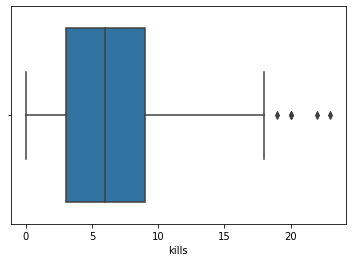

In [19]:
sns.boxplot(x = "kills", orient = "v", data = akshan_df)